In [117]:
import pandas as pd
import os
from scipy import stats  
import matplotlib.pyplot as plt
import numpy as np

In [118]:
data = pd.read_csv('project_data/full_dataset_roberta.csv')

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_11938/51691811.py:1: DtypeWarning: Columns (27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('project_data/full_dataset_roberta.csv')


In [119]:
data = data.loc[data['group_depression'] | data['group_anxiety']]

# Simple comparisons

In [120]:
OUTCOME_VAR = 'ROBERTA_NA'

## Mean vs median

MannwhitneyuResult(statistic=np.float64(167521.0), pvalue=np.float64(6.02065464350869e-53))


Text(0.5, 1.0, 'Distribution of difference between mean and median VADER NA scores for raw data')

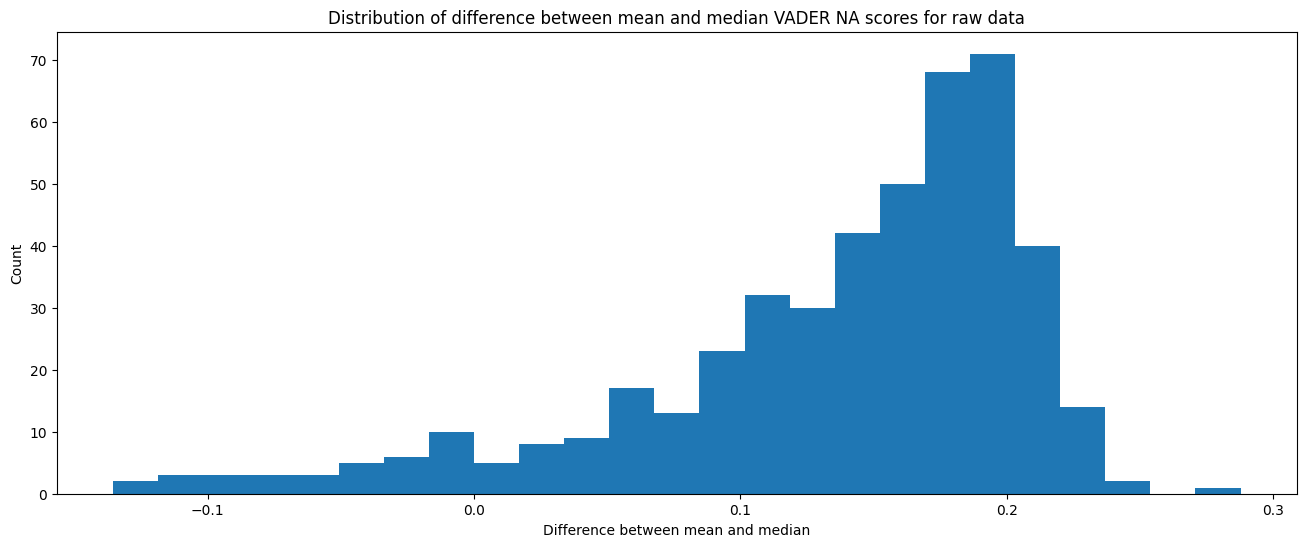

In [121]:
df = data.groupby('user_id').agg({
    OUTCOME_VAR: ['mean', 'median'],
})

print(stats.mannwhitneyu(
    df[(OUTCOME_VAR, 'mean')],
    df[(OUTCOME_VAR, 'median')]
))

fig, ax = plt.subplots(figsize=(16, 6))
ax.hist(
    df[(OUTCOME_VAR, 'mean')] - df[(OUTCOME_VAR, 'median')],
    bins=25,
)
ax.set_xlabel('Difference between mean and median')
ax.set_ylabel('Count')
ax.set_title('Distribution of difference between mean and median VADER NA scores for raw data')

## NA levels

In [122]:
data_aggregated_level = data.groupby('user_id').agg({
    OUTCOME_VAR: 'mean',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna()

stats.mannwhitneyu(
    data_aggregated_level.loc[data_aggregated_level.group_depression][OUTCOME_VAR],
    data_aggregated_level.loc[data_aggregated_level.group_anxiety][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(29385.0), pvalue=np.float64(0.03954417630986827))

In [123]:
data_aggregated_level.groupby('group_depression').mean(numeric_only=True)

,ROBERTA_NA,group_anxiety
group_depression,,
False,0.279185,1.0
True,0.297764,0.0


## variability

In [124]:
data_aggregated_spread = data.groupby('user_id').agg({
    OUTCOME_VAR: 'std',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna()

stats.mannwhitneyu(
    data_aggregated_spread.loc[data_aggregated_spread.group_depression][OUTCOME_VAR],
    data_aggregated_spread.loc[data_aggregated_spread.group_anxiety][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(27236.0), pvalue=np.float64(0.5816276605367613))

In [125]:
data_aggregated_spread.groupby('group_depression').mean(numeric_only=True)

,ROBERTA_NA,group_anxiety
group_depression,,
False,0.318957,1.0
True,0.319644,0.0


## Plot mean and SD

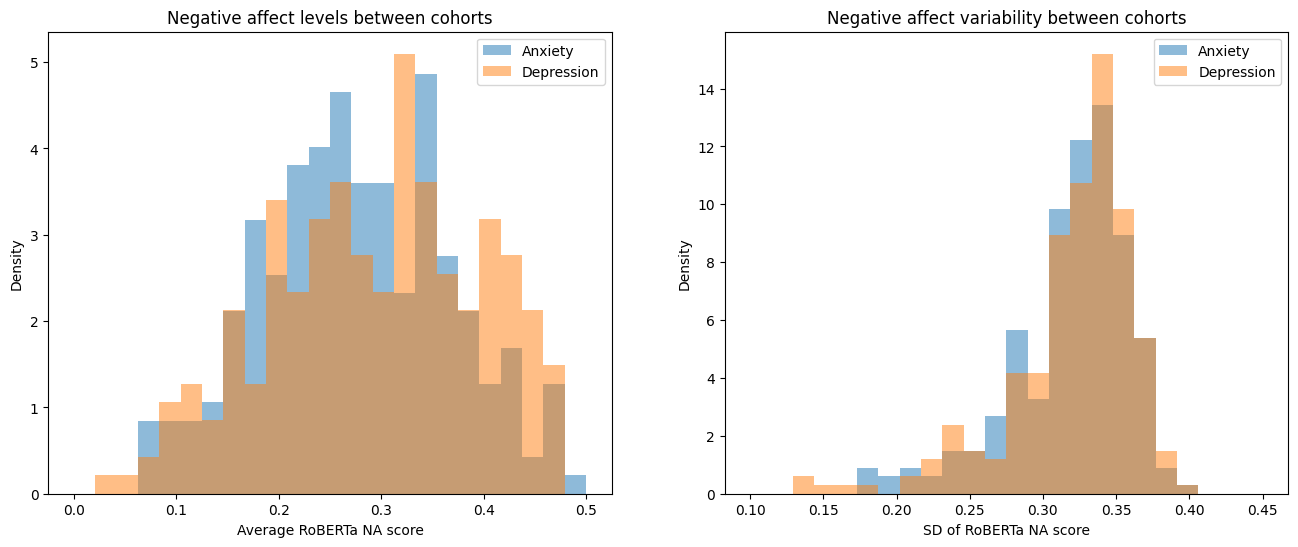

In [126]:
fig,ax = plt.subplots(1,2,figsize=(16,6))

bins = np.linspace(0, 0.5, 25)

ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_anxiety]['ROBERTA_NA'], alpha = 0.5, density=True, bins=bins, label='Anxiety')
ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_depression]['ROBERTA_NA'], alpha = 0.5, density=True, bins=bins, label='Depression')
ax[0].set_title('Negative affect levels between cohorts')
ax[0].set_xlabel('Average RoBERTa NA score')
ax[0].set_ylabel('Density')
ax[0].legend()

bins = np.linspace(0.1, 0.45, 25)

ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_anxiety]['ROBERTA_NA'], alpha = 0.5, density=True, bins=bins, label='Anxiety')
ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_depression]['ROBERTA_NA'], alpha = 0.5, density=True, bins=bins, label='Depression')
ax[1].set_title('Negative affect variability between cohorts')
ax[1].set_xlabel('SD of RoBERTa NA score')
ax[1].set_ylabel('Density')
ax[1].legend()

plt.savefig('figures/na_histograms_raw_roberta.png', dpi=400, bbox_inches='tight')

## 6-hour-window

In [127]:
windowed_data = pd.read_csv('project_data/windowed_mean_data_roberta.csv', index_col=0)
windowed_data = windowed_data.loc[windowed_data['group_depression'] + windowed_data['group_anxiety'] > 0]

In [128]:
windowed_data

,user_id,created_at,ROBERTA_NA,group_anxiety,group_depression,comorbid,gender_female,19-29,30-39,<=18,>=40,day_of_week,gender
0,uANX011,2018-01-01 10:42:48+00:00,0.061874,1.0,0.0,0.0,1.0,0.5702,0.2468,0.0284,0.1546,0.0,female
1,uANX011,2018-01-01 10:59:17+00:00,0.061874,1.0,0.0,0.0,1.0,0.5702,0.2468,0.0284,0.1546,0.0,female
2,uANX011,2018-01-01 11:01:06+00:00,0.061874,1.0,0.0,0.0,1.0,0.5702,0.2468,0.0284,0.1546,0.0,female
3,uANX011,2018-01-01 11:02:00+00:00,0.061874,1.0,0.0,0.0,1.0,0.5702,0.2468,0.0284,0.1546,0.0,female
4,uANX011,2018-01-05 17:55:50+00:00,0.399146,1.0,0.0,0.0,1.0,0.5702,0.2468,0.0284,0.1546,4.0,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...
409744,uSAD005,2020-04-30 07:42:28+00:00,0.002804,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0,female
409745,uSAD005,2020-04-30 07:42:59+00:00,0.002804,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0,female
409746,uSAD005,2020-04-30 07:46:32+00:00,0.002804,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0,female
409747,uSAD005,2020-04-30 16:16:10+00:00,0.003006,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0,female


## Means vs medians

MannwhitneyuResult(statistic=np.float64(113207.0), pvalue=np.float64(0.06608080605833294))


Text(0.5, 1.0, 'Distribution of difference between mean and median VADER NA scores for raw data')

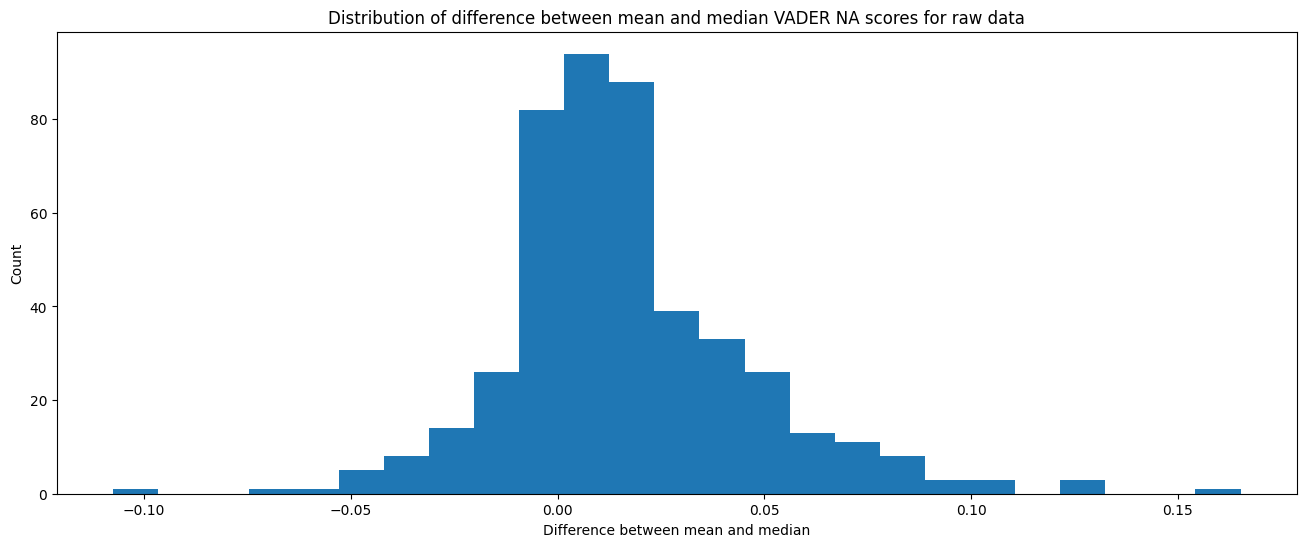

In [129]:
df = windowed_data.groupby('user_id').agg({
    OUTCOME_VAR: ['mean', 'median'],
})

print(stats.mannwhitneyu(
    df[(OUTCOME_VAR, 'mean')],
    df[(OUTCOME_VAR, 'median')]
))

fig, ax = plt.subplots(figsize=(16, 6))
ax.hist(
    df[(OUTCOME_VAR, 'mean')] - df[(OUTCOME_VAR, 'median')],
    bins=25,
)
ax.set_xlabel('Difference between mean and median')
ax.set_ylabel('Count')
ax.set_title('Distribution of difference between mean and median VADER NA scores for raw data')

### Standard deviation

In [130]:
data_aggregated_spread = windowed_data.groupby('user_id').agg({
    OUTCOME_VAR: 'std',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna().reset_index()

stats.mannwhitneyu(
    data_aggregated_spread.loc[data_aggregated_spread.group_depression == 1][OUTCOME_VAR],
    data_aggregated_spread.loc[data_aggregated_spread.group_anxiety == 1][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(26259.0), pvalue=np.float64(0.8936943486646487))

In [131]:
data_aggregated_spread.groupby('group_depression').mean(numeric_only=True)

,ROBERTA_NA,group_anxiety
group_depression,,
0.0,0.178973,1.0
1.0,0.178578,0.0


## General valence

In [135]:
data_agregated_level = windowed_data.groupby('user_id').agg({
    OUTCOME_VAR: 'mean',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna().reset_index()

stats.mannwhitneyu(
    data_agregated_level.loc[data_agregated_level.group_depression == 1][OUTCOME_VAR],
    data_agregated_level.loc[data_agregated_level.group_anxiety == 1][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(29364.0), pvalue=np.float64(0.04097844782456628))

In [136]:
data_agregated_level.groupby('group_depression').mean(numeric_only=True)

,ROBERTA_NA,group_anxiety
group_depression,,
0.0,0.283538,1.0
1.0,0.302042,0.0


## Difference between means and medians

MannwhitneyuResult(statistic=np.float64(113207.0), pvalue=np.float64(0.06608080605833294))

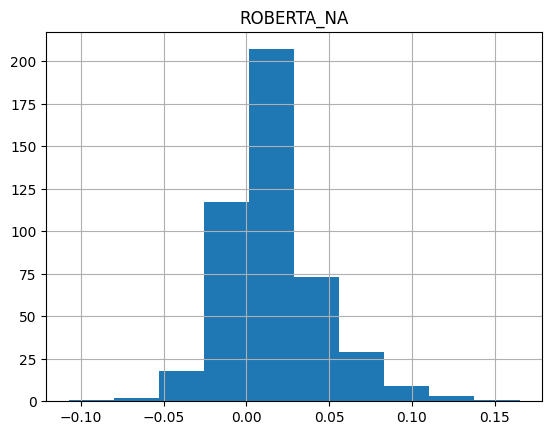

In [137]:
means = data_aggregated[['user_id', OUTCOME_VAR]].groupby('user_id').mean()
medians = data_aggregated[['user_id', OUTCOME_VAR]].groupby('user_id').median()

(means-medians).hist()
from scipy import stats  
stats.mannwhitneyu(
    means[OUTCOME_VAR],
    medians[OUTCOME_VAR])

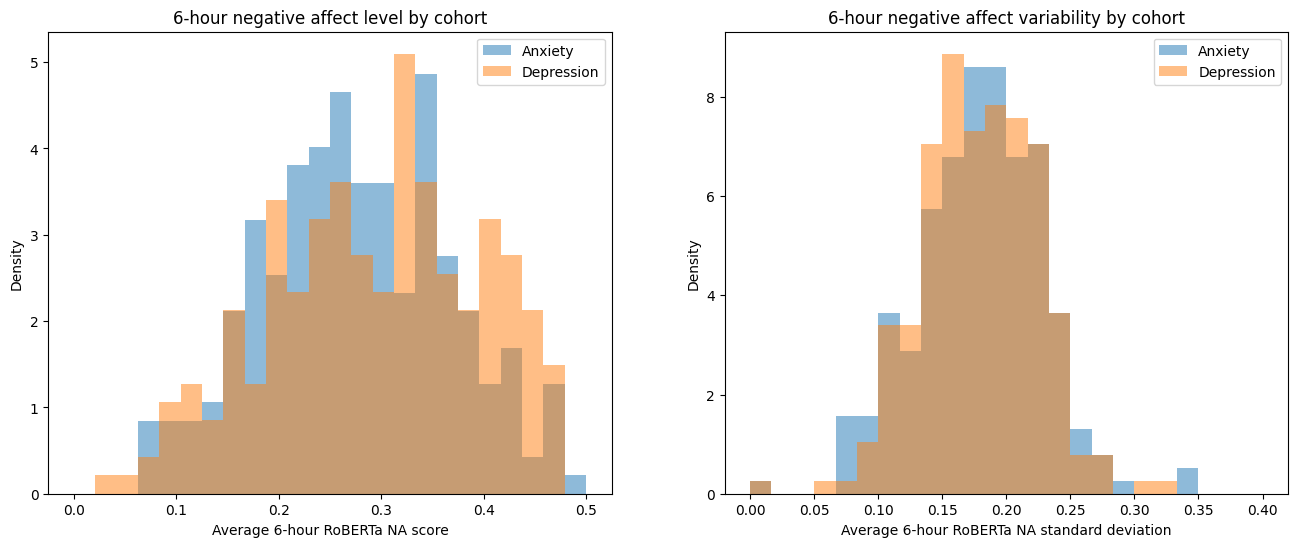

In [138]:
bins = np.linspace(0, 0.5,25)

fig,ax = plt.subplots(1,2,figsize=(16,6))

ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_anxiety == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Anxiety')
ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_depression == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Depression')
ax[0].legend()
ax[0].set_title('6-hour negative affect level by cohort')
ax[0].set_ylabel('Density')
ax[0].set_xlabel('Average 6-hour RoBERTa NA score')

bins = np.linspace(0, 0.4,25)

ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_anxiety == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Anxiety')
ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_depression == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Depression')
ax[1].legend()
ax[1].set_title('6-hour negative affect variability by cohort')
ax[1].set_ylabel('Density')
ax[1].set_xlabel('Average 6-hour RoBERTa NA standard deviation')

plt.savefig('figures/na_histograms_6hr_roberta.png', dpi=400, bbox_inches='tight')

## Daily affect variance

In [139]:
daily_data = pd.read_csv('project_data/daily_mean_data_roberta.csv', index_col=0)
daily_data = daily_data.loc[daily_data['group_depression'] + daily_data['group_anxiety'] > 0]

## Means vs medians

MannwhitneyuResult(statistic=np.float64(125065.0), pvalue=np.float64(1.7498048272276179e-06))


Text(0.5, 1.0, 'Distribution of difference between mean and median VADER NA scores for raw data')

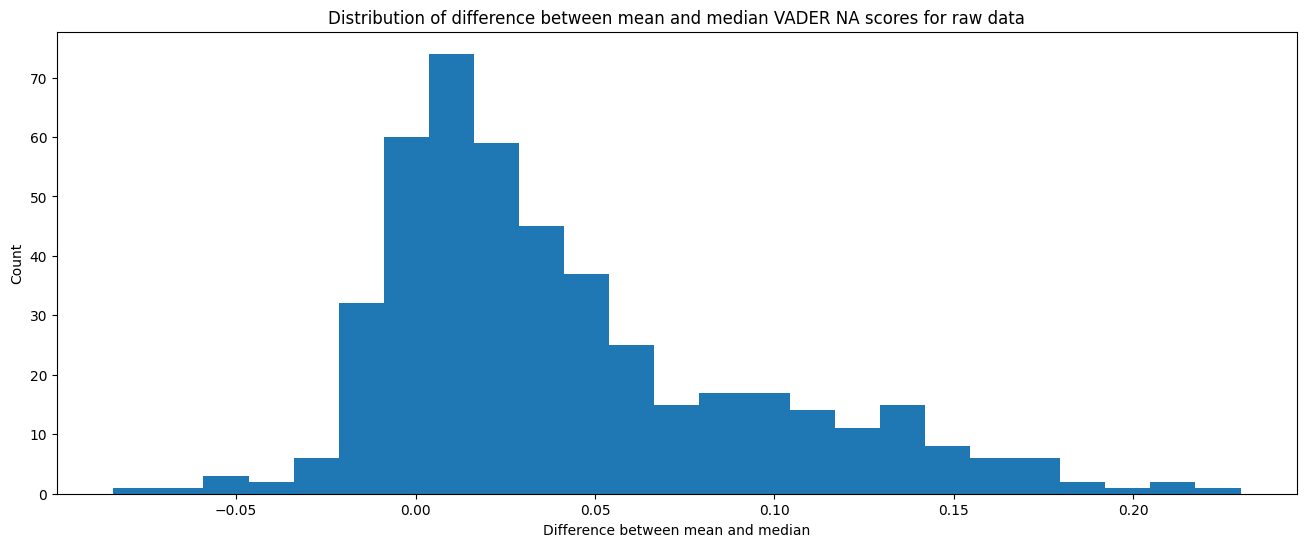

In [140]:
df = daily_data.groupby('user_id').agg({
    OUTCOME_VAR: ['mean', 'median'],
})

print(stats.mannwhitneyu(
    df[(OUTCOME_VAR, 'mean')],
    df[(OUTCOME_VAR, 'median')]
))

fig, ax = plt.subplots(figsize=(16, 6))
ax.hist(
    df[(OUTCOME_VAR, 'mean')] - df[(OUTCOME_VAR, 'median')],
    bins=25,
)
ax.set_xlabel('Difference between mean and median')
ax.set_ylabel('Count')
ax.set_title('Distribution of difference between mean and median VADER NA scores for raw data')

## NA level

In [141]:
data_aggregated_level = daily_data.groupby('user_id').agg({
    OUTCOME_VAR: 'mean',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna().reset_index()

stats.mannwhitneyu(
    data_aggregated_level.loc[data_aggregated_level.group_depression == 1][OUTCOME_VAR],
    data_aggregated_level.loc[data_aggregated_level.group_anxiety == 1][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(29318.0), pvalue=np.float64(0.044274765062881846))

In [142]:
data_aggregated_level.groupby('group_depression').mean(numeric_only=True)

,ROBERTA_NA,group_anxiety
group_depression,,
False,0.274915,1.0
True,0.292957,0.0


## Daily affect variability

In [143]:
data_aggregated_spread = daily_data.groupby('user_id').agg({
    OUTCOME_VAR: 'std',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna().reset_index()

stats.mannwhitneyu(
    data_aggregated_spread.loc[data_aggregated_spread.group_depression == 1][OUTCOME_VAR],
    data_aggregated_spread.loc[data_aggregated_spread.group_anxiety == 1][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(26830.0), pvalue=np.float64(0.790077605090489))

In [144]:
data_aggregated_spread.groupby('group_depression').mean(numeric_only=True)

,ROBERTA_NA,group_anxiety
group_depression,,
False,0.213358,1.0
True,0.215444,0.0


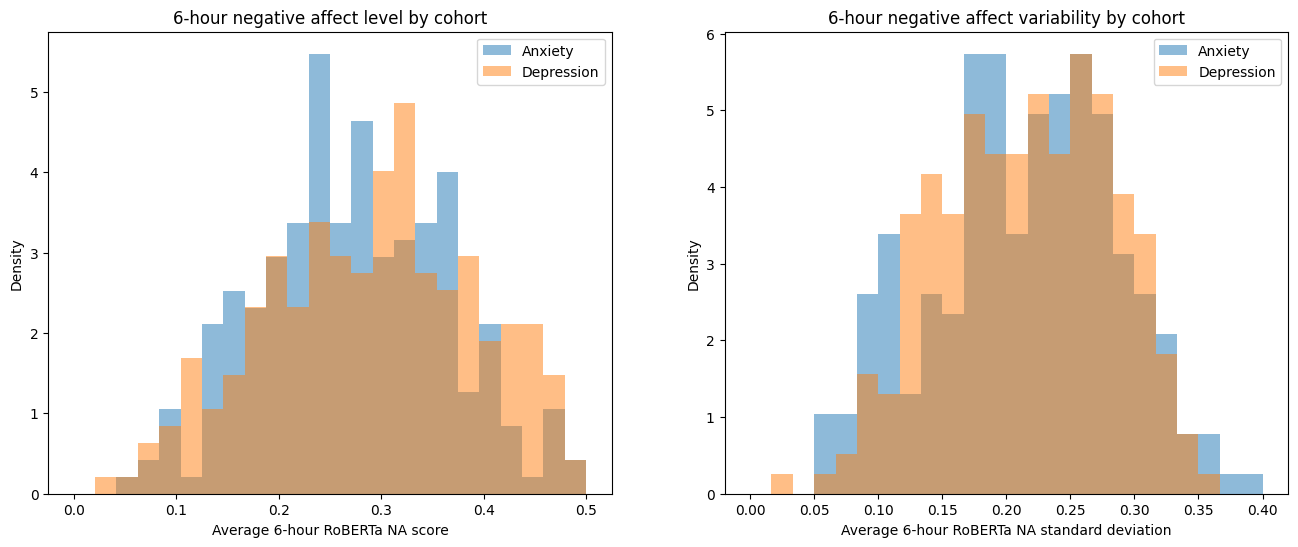

In [145]:
bins = np.linspace(0, 0.5,25)

fig,ax = plt.subplots(1,2,figsize=(16,6))

ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_anxiety][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Anxiety')
ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_depression][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Depression')
ax[0].legend()
ax[0].set_title('6-hour negative affect level by cohort')
ax[0].set_ylabel('Density')
ax[0].set_xlabel('Average 6-hour RoBERTa NA score')

bins = np.linspace(0, 0.4,25)

ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_anxiety == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Anxiety')
ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_depression == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Depression')
ax[1].legend()
ax[1].set_title('6-hour negative affect variability by cohort')
ax[1].set_ylabel('Density')
ax[1].set_xlabel('Average 6-hour RoBERTa NA standard deviation')

plt.savefig('figures/na_histograms_daily_roberta.png', dpi=400, bbox_inches='tight')